In [14]:
import os
import numpy as np
import pandas as pd
import astropy.units as u
import matplotlib.pyplot as plt

from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
from astroquery.simbad import Simbad
from matplotlib.patches import Rectangle
from astroquery.hips2fits import hips2fits
from astropy.coordinates import SkyCoord, Angle

font = {'family' : 'gill sans',
         'size'   : 12,
         'serif':  'cmr10'
         }

plt.rc('font', **font)
plt.rc('axes', unicode_minus = False)

In [15]:
main_directory = Path().resolve()

In [16]:
def random_effects_mean(vals, sigmas):
    vals = np.asarray(vals, dtype = float)
    sigmas = np.asarray(sigmas, dtype = float)
    var = sigmas ** 2

    w  = 1.0 / var
    mu = (w * vals).sum() / w.sum()

    Q  = (w * (vals - mu) ** 2).sum()
    df = len(vals) - 1
    c  = w.sum() - (w ** 2).sum() / w.sum()
    T2 = max(0.0, (Q - df) / c) if c > 0 else 0.0

    w_re = 1.0 / (var + T2)
    mean = (w_re * vals).sum() / w_re.sum()
    std  = np.sqrt(1.0 / w_re.sum())
    return mean, std

In [17]:
def random_effects_with_heterogeneity(vals, sigmas):
    vals = np.asarray(vals, dtype = float)
    sigmas = np.asarray(sigmas, dtype = float)
    var = sigmas ** 2

    w = 1.0 / var
    mu_fixed = (w * vals).sum() / w.sum()

    Q = (w * (vals - mu_fixed) ** 2).sum()
    df = len(vals) - 1
    c = w.sum() - (w ** 2).sum() / w.sum()
    T2 = max(0.0, (Q - df) / c) if c > 0 else 0.0
    tau = np.sqrt(T2)

    w_re = 1.0 / (var + T2)
    mean = (w_re * vals).sum() / w_re.sum()
    se_mean = np.sqrt(1.0 / w_re.sum())

    return mean, se_mean, tau

In [18]:
records_O = []
records_S = []
records_Fe = []

for galaxy_name in os.listdir(main_directory):
    galaxy_path = main_directory / galaxy_name
    if galaxy_path.name.startswith(".") or not galaxy_path.is_dir():
        continue
        
    for region_name in os.listdir(galaxy_path):
        region_path = galaxy_path / region_name
        if region_path.name.startswith(".") or not region_path.is_dir():
            continue

        records_O_region = []
        records_S_region = []
        records_Fe_region = []
    
        for target_name in os.listdir(region_path):
            target_path = region_path / target_name
            if target_path.name.startswith("unused") or target_path.name.startswith(".") or not target_path.is_dir():
                continue
        
            O_path = target_path / "O.txt"
            
            if O_path.is_file():
                
                with open(O_path, "r") as file:
                    
                    lines = file.readlines()
                    OI_H = float(lines[0].strip())
                    sigma_OI_H = float(lines[1].strip())
        
                records_O_region.append({
                        "OI_H": OI_H,
                        "sigma_OI_H": sigma_OI_H,
                    })
                
            S_path = target_path / "S.txt"
            
            if S_path.is_file():
                
                with open(S_path, "r") as file:
                    
                    lines = file.readlines()
                    SII_H = float(lines[0].strip())
                    sigma_SII_H = float(lines[1].strip())
        
                records_S_region.append({
                        "SII_H": SII_H,
                        "sigma_SII_H": sigma_SII_H,
                    })
                
            Fe_path = target_path / "Fe.txt"
            
            if Fe_path.is_file():
                
                with open(Fe_path, "r") as file:
                    
                    lines = file.readlines()
                    FeII_H = float(lines[0].strip())
                    sigma_FeII_H = float(lines[1].strip())
        
                records_Fe_region.append({
                        "FeII_H": FeII_H,
                        "sigma_FeII_H": sigma_FeII_H,
                    })
                
        if records_O_region:
            O_vals = [r["OI_H"] for r in records_O_region]
            O_sigmas = [r["sigma_OI_H"] for r in records_O_region]
            O_sight_lines, se_O_sight_lines, tau_O_sight_lines = random_effects_with_heterogeneity(O_vals, O_sigmas)
            records_O.append({
                "galaxy": galaxy_name,
                "region": region_name,
                "O_sight_lines": O_sight_lines,
                "se_O_sight_lines": se_O_sight_lines, 
                "tau_O_sight_lines": tau_O_sight_lines, 
                "sight_lines_count": len(O_vals)
            })

        if records_S_region:
            S_vals = [r["SII_H"] for r in records_S_region]
            S_sigmas = [r["sigma_SII_H"] for r in records_S_region]
            S_sight_lines, se_S_sight_lines, tau_S_sight_lines = random_effects_with_heterogeneity(S_vals, S_sigmas)
            records_S.append({
                "galaxy": galaxy_name,
                "region": region_name,
                "S_sight_lines": S_sight_lines,
                "se_S_sight_lines": se_S_sight_lines, 
                "tau_S_sight_lines": tau_S_sight_lines, 
                "sight_lines_count": len(S_vals)
            })

        if records_Fe_region:
            Fe_vals = [r["FeII_H"] for r in records_Fe_region]
            Fe_sigmas = [r["sigma_FeII_H"] for r in records_Fe_region]
            Fe_sight_lines, se_Fe_sight_lines, tau_Fe_sight_lines = random_effects_with_heterogeneity(Fe_vals, Fe_sigmas)
            records_Fe.append({
                "galaxy": galaxy_name,
                "region": region_name,
                "Fe_sight_lines": Fe_sight_lines,
                "se_Fe_sight_lines": se_Fe_sight_lines, 
                "tau_Fe_sight_lines": tau_Fe_sight_lines, 
                "sight_lines_count": len(Fe_vals)
            })

In [19]:
df_S_sight_lines = pd.DataFrame(records_S)

df_S_HII = pd.DataFrame({
    "region" : ["30 Doradus", "LMC N11B", "SMC N66A", "SMC N81", "SMC N88A", "SMC N90"], 
    "S": [6.99, 6.72, 6.35, 6.34, 6.33, 6.38],
    "sigma_low": [0.10, 0.02, 0.03, 0.03, 0.07, 0.04],
    "sigma_high": [0.10, 0.02, 0.03, 0.03, 0.10, 0.04],
})

df_S = df_S_HII.merge(df_S_sight_lines[["region", "S_sight_lines", "se_S_sight_lines", "tau_S_sight_lines", "sight_lines_count"]], on = "region", how = "outer", validate = "one_to_one")

df_Fe_sight_lines = pd.DataFrame(records_Fe)

df_Fe_HII = pd.DataFrame({
    "region" : ["30 Doradus", "LMC N11B", "SMC N66A", "SMC N81", "SMC N88A", "SMC N90"], 
    "Fe_b" : [5.70, 5.43, 5.17, 5.26, 5.52, 4.72], 
    "sigma_Fe_b" : [np.nan, 0.02, 0.03, 0.02, 0.02, np.nan], 
    "Fe_c" : [5.90, 5.43, 5.26, 5.48, 5.99, 4.68], 
    "sigma_Fe_c" : [0.07, 0.02, 0.02, 0.02, 0.03, np.nan], 
    "Fe" : [np.nan, np.nan, np.nan, np.nan, 5.59, np.nan], 
    "sigma_Fe" : [np.nan, np.nan, np.nan, np.nan, 0.03, np.nan]
})

df_Fe = df_Fe_HII.merge(df_Fe_sight_lines[["region", "Fe_sight_lines", "se_Fe_sight_lines", "tau_Fe_sight_lines", "sight_lines_count"]], on = "region", how = "outer", validate = "one_to_one")

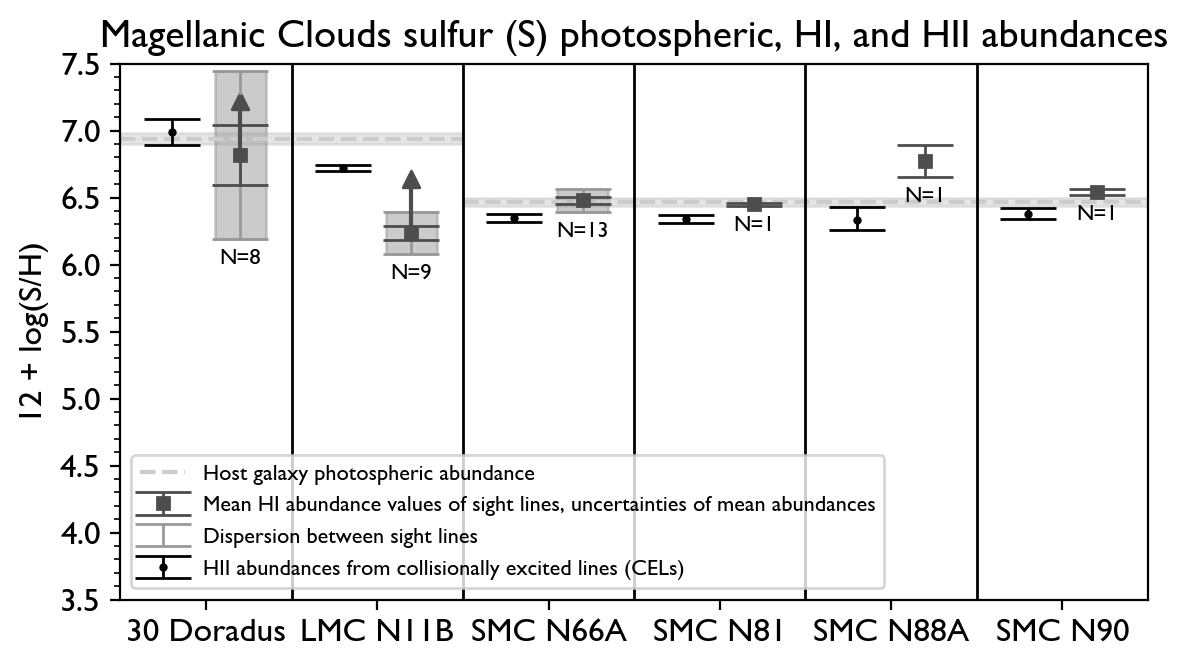

In [20]:
fig, ax = plt.subplots(figsize = (len(records_S), 3.5), dpi = 200)
x = np.arange(len(records_S))
x_left_offset = x - 0.2
x_right_offset = x + 0.2

ax.fill_between([-0.5, 1.5], 6.94 - 0.04, 6.94 + 0.04, color = "0.8", alpha = 0.5)
ax.hlines(6.94, xmin = -0.5, xmax = 1.5, color = "0.8", linestyle = "--", label = "Host galaxy photospheric abundance")
ax.fill_between([1.5, 5.5], 6.47 - 0.03, 6.47 + 0.03, color = "0.8", alpha = 0.5)
ax.hlines(6.47, xmin = 1.5, xmax = 5.5, color = "0.8", linestyle = "--")

nonzero_tau_mask = df_S["tau_S_sight_lines"] != 0
x_right_offset_nonzero = x_right_offset[nonzero_tau_mask.to_numpy()]
S_sight_lines_nonzero = df_S["S_sight_lines"][nonzero_tau_mask]
tau_S_sight_lines_nonzero = df_S["tau_S_sight_lines"][nonzero_tau_mask]

ax.errorbar(x_right_offset, df_S["S_sight_lines"], yerr = df_S["se_S_sight_lines"], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0.3", ecolor = "0.3", label = r"Mean HI abundance values of sight lines, uncertainties of mean abundances", zorder = 3) # make this on top

ax.errorbar(x_right_offset_nonzero, S_sight_lines_nonzero, yerr = tau_S_sight_lines_nonzero, fmt = "s", markersize = 0, capsize = 10, lw = 1, color = "0.6", ecolor = "0.6", label = r"Dispersion between sight lines",)

shade_width = 0.3

for xi, y, tau in zip(x_right_offset, df_S["S_sight_lines"], df_S["tau_S_sight_lines"]):
    if tau != 0: 
        rect = Rectangle((xi - shade_width / 2, y - tau), shade_width, 2 * tau, facecolor = "0.6", edgecolor = "0.6", alpha = 0.5)
        ax.add_patch(rect)

for xi, y, count, se, tau in zip(x_right_offset, df_S["S_sight_lines"], df_S["sight_lines_count"], df_S["se_S_sight_lines"], df_S["tau_S_sight_lines"]):
    bottom = np.maximum(se, tau)
    ax.text(xi, y - bottom - 0.15, f"N={count}", color = "black", fontsize = 8, ha = "center", va = "center", weight = "bold")

ax.errorbar(x_left_offset, df_S["S"], yerr = [df_S["sigma_low"], df_S["sigma_high"]], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0", ecolor = "0", label = r"HII abundances from collisionally excited lines (CELs)")

for i in range(len(records_Fe)):
    ax.axvline(i + 0.5, linestyle = "-", linewidth = 1, color = "black")

ax.vlines(x_right_offset[0], df_S["S_sight_lines"][0], df_S["S_sight_lines"][0] + 0.45, facecolor = "0.3", edgecolor = "0.3")
ax.scatter(x_right_offset[0], df_S["S_sight_lines"][0] + 0.4, marker = "^", facecolor = "0.3", edgecolor = "0.3")

ax.vlines(x_right_offset[1], df_S["S_sight_lines"][1], df_S["S_sight_lines"][1] + 0.45, facecolor = "0.3", edgecolor = "0.3")
ax.scatter(x_right_offset[1], df_S["S_sight_lines"][1] + 0.4, marker = "^", facecolor = "0.3", edgecolor = "0.3")

ax.set_xticks(x)
ax.set_xticklabels(df_Fe["region"])
ax.set_ylabel(r"12 + log(S/H)")
ax.set_xlim(-0.5, len(records_Fe) - 0.5)
ax.set_ylim(3.5, 7.5)
ax.set_title("Magellanic Clouds sulfur (S) photospheric, HI, and HII abundances")
ax.minorticks_on()
ax.xaxis.set_tick_params(which = "minor", bottom = False)
ax.legend(fontsize = 8)

fig.tight_layout()

plt.savefig('S.png', dpi = 300)
plt.show()

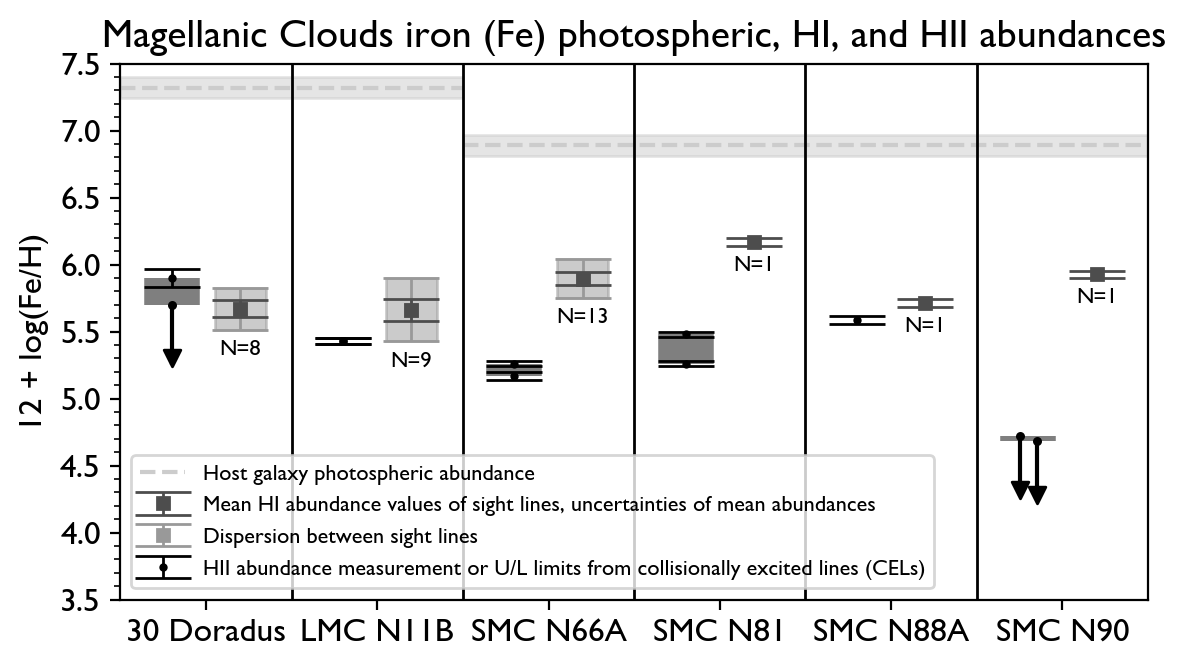

In [21]:
fig, ax = plt.subplots(figsize = (len(records_Fe), 3.5), dpi = 200)
x = np.arange(len(records_Fe))
x_left_offset = x - 0.2
x_right_offset = x + 0.2

ax.fill_between([-0.5, 1.5], 7.32 - 0.08, 7.32 + 0.08, alpha = 0.5, color = "0.8")
ax.hlines(7.32, xmin = -0.5, xmax = 1.5, color = "0.8", linestyle = "--", label = "Host galaxy photospheric abundance")
ax.fill_between([1.5, 5.5], 6.89 - 0.08, 6.89 + 0.08, alpha = 0.5, color = "0.8")
ax.hlines(6.89, xmin = 1.5, xmax = 5.5, color = "0.8", linestyle = "--")
ax.fill_between([5.5, 6.5], 6.04 - 0.2, 6.04 + 0.2, alpha = 0.2, color = "0.8")
ax.hlines(6.04, xmin = 5.5, xmax = 6.5, color = "0.8", linestyle = "--")

ax.errorbar(x_right_offset, df_Fe["Fe_sight_lines"], yerr = df_Fe["se_Fe_sight_lines"], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0.3", ecolor = "0.3", label = r"Mean HI abundance values of sight lines, uncertainties of mean abundances", zorder = 100)

nonzero_tau_mask = df_Fe["tau_Fe_sight_lines"] != 0
x_right_offset_nonzero = x_right_offset[nonzero_tau_mask.to_numpy()]
Fe_sight_lines_nonzero = df_Fe["Fe_sight_lines"][nonzero_tau_mask]
tau_Fe_sight_lines_nonzero = df_Fe["tau_Fe_sight_lines"][nonzero_tau_mask]
ax.errorbar(x_right_offset_nonzero, Fe_sight_lines_nonzero, yerr = tau_Fe_sight_lines_nonzero, fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0.6", ecolor = "0.6", label = r"Dispersion between sight lines")

shade_width = 0.3

for xi, y, tau in zip(x_right_offset, df_Fe["Fe_sight_lines"], df_Fe["tau_Fe_sight_lines"]):
    if tau != 0: 
        rect = Rectangle((xi - shade_width / 2, y - tau), shade_width, 2 * tau, facecolor = "0.6", edgecolor = "0.6", alpha = 0.5)
        ax.add_patch(rect)

for xi, y, count, se, tau in zip(x_right_offset, df_Fe["Fe_sight_lines"], df_Fe["sight_lines_count"], df_Fe["se_Fe_sight_lines"], df_Fe["tau_Fe_sight_lines"]):
    bottom = np.maximum(se, tau)
    ax.text(xi, y - bottom - 0.15, f"N={count}", color = "black", fontsize = 8, ha = "center", va = "center", weight = "bold")

for i, row in df_Fe.iterrows():
    if i == 0:
        ax.errorbar(x_left_offset[i], row["Fe_c"], yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0", label = r"HII abundance measurement or U/L limits from collisionally excited lines (CELs)")
        ax.scatter(x_left_offset[i], row["Fe_b"], marker = ".", s = 20, color = "0")
        ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_b"] - 0.45, color = "0")
        ax.scatter(x_left_offset[i], row["Fe_b"] - 0.4, marker = "v", color = "0")
        ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "0", alpha = 0.5)
    elif i == 4:
        # ax.errorbar(x_left_offset[i], row["Fe_b"], yerr = row["sigma_Fe_b"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        # ax.errorbar(x_left_offset[i], row["Fe_c"], yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        # ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "0", alpha = 0.5)
        ax.errorbar(x_left_offset[i], row["Fe"], yerr = row["sigma_Fe"], fmt = ".", markersize = 4, capsize = 10, color = "0") # , label = r"HII abundance measurement from collisionally excited lines (CELs)")
    elif i == 5:
        ax.scatter(x_left_offset[i] - 0.05, row["Fe_b"], marker = ".", s = 20, color = "0")
        ax.vlines(x_left_offset[i] - 0.05, row["Fe_b"], row["Fe_b"] - 0.45, color = "0")
        ax.scatter(x_left_offset[i] - 0.05, row["Fe_b"] - 0.4, marker = "v", color = "0")

        ax.scatter(x_left_offset[i] + 0.05, row["Fe_c"], marker = ".", s = 20, color = "0")
        ax.vlines(x_left_offset[i] + 0.05, row["Fe_c"], row["Fe_b"] - 0.45, color = "0")
        ax.scatter(x_left_offset[i] + 0.05, row["Fe_c"] - 0.4, marker = "v", color = "0")

        ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "0", alpha = 0.5)
    else:
        ax.errorbar(x_left_offset[i], row["Fe_b"], yerr = row["sigma_Fe_b"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        ax.errorbar(x_left_offset[i], row["Fe_c"], yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "0", alpha = 0.5)

for i in range(len(records_Fe)):
    ax.axvline(i + 0.5, linestyle = "-", linewidth = 1, color = "black")

ax.set_xticks(x)
ax.set_xticklabels(df_Fe["region"])
ax.set_ylabel(r"12 + log(Fe/H)")
ax.set_xlim(-0.5, len(records_Fe) - 0.5)
ax.set_ylim(3.5, 7.5)
ax.set_title("Magellanic Clouds iron (Fe) photospheric, HI, and HII abundances")
ax.minorticks_on()
ax.xaxis.set_tick_params(which = "minor", bottom = False)
ax.legend(fontsize = 8)

fig.tight_layout()

plt.savefig('Fe.png', dpi = 300)
plt.show()

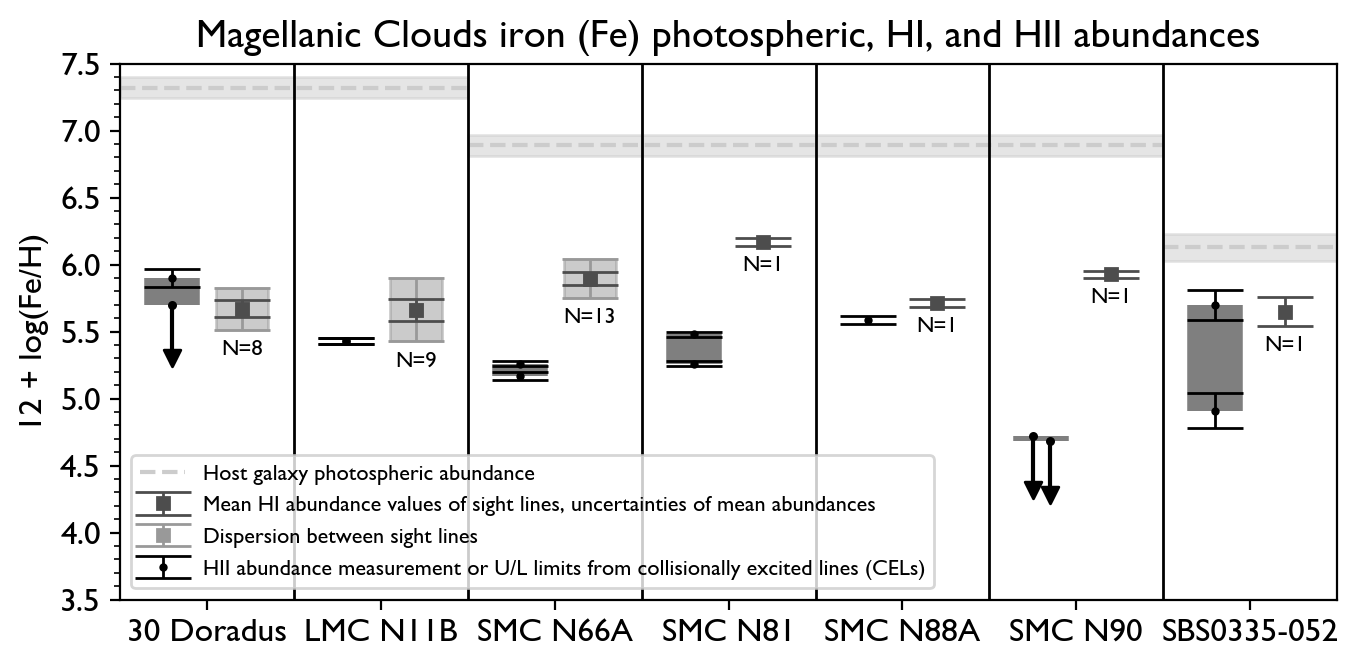

In [22]:
fig, ax = plt.subplots(figsize = (len(records_Fe) + 1, 3.5), dpi = 200)
x = np.arange(len(records_Fe))
x_left_offset = x - 0.2
x_right_offset = x + 0.2

ax.fill_between([-0.5, 1.5], 7.32 - 0.08, 7.32 + 0.08, alpha = 0.5, color = "0.8")
ax.hlines(7.32, xmin = -0.5, xmax = 1.5, color = "0.8", linestyle = "--", label = "Host galaxy photospheric abundance")
ax.fill_between([1.5, 5.5], 6.89 - 0.08, 6.89 + 0.08, alpha = 0.5, color = "0.8")
ax.hlines(6.89, xmin = 1.5, xmax = 5.5, color = "0.8", linestyle = "--")
ax.fill_between([5.5, 6.5], 6.13 - 0.1, 6.13 + 0.1, alpha = 0.5, color = "0.8")
ax.hlines(6.13, xmin = 5.5, xmax = 6.5, color = "0.8", linestyle = "--") # Asplund+2009 Iron - (Asplund+2009 Oxygen - James+2014 Oxygen)

ax.errorbar(x_right_offset, df_Fe["Fe_sight_lines"], yerr = df_Fe["se_Fe_sight_lines"], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0.3", ecolor = "0.3", label = r"Mean HI abundance values of sight lines, uncertainties of mean abundances", zorder = 100)

nonzero_tau_mask = df_Fe["tau_Fe_sight_lines"] != 0
x_right_offset_nonzero = x_right_offset[nonzero_tau_mask.to_numpy()]
Fe_sight_lines_nonzero = df_Fe["Fe_sight_lines"][nonzero_tau_mask]
tau_Fe_sight_lines_nonzero = df_Fe["tau_Fe_sight_lines"][nonzero_tau_mask]
ax.errorbar(x_right_offset_nonzero, Fe_sight_lines_nonzero, yerr = tau_Fe_sight_lines_nonzero, fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0.6", ecolor = "0.6", label = r"Dispersion between sight lines")

shade_width = 0.3

for xi, y, tau in zip(x_right_offset, df_Fe["Fe_sight_lines"], df_Fe["tau_Fe_sight_lines"]):
    if tau != 0: 
        rect = Rectangle((xi - shade_width / 2, y - tau), shade_width, 2 * tau, facecolor = "0.6", edgecolor = "0.6", alpha = 0.5)
        ax.add_patch(rect)

for xi, y, count, se, tau in zip(x_right_offset, df_Fe["Fe_sight_lines"], df_Fe["sight_lines_count"], df_Fe["se_Fe_sight_lines"], df_Fe["tau_Fe_sight_lines"]):
    bottom = np.maximum(se, tau)
    ax.text(xi, y - bottom - 0.15, f"N={count}", color = "black", fontsize = 8, ha = "center", va = "center", weight = "bold")

for i, row in df_Fe.iterrows():
    if i == 0:
        ax.errorbar(x_left_offset[i], row["Fe_c"], yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0", label = r"HII abundance measurement or U/L limits from collisionally excited lines (CELs)")
        ax.scatter(x_left_offset[i], row["Fe_b"], marker = ".", s = 20, color = "0")
        ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_b"] - 0.45, color = "0")
        ax.scatter(x_left_offset[i], row["Fe_b"] - 0.4, marker = "v", color = "0")
        ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "0", alpha = 0.5)
    elif i == 4:
        # ax.errorbar(x_left_offset[i], row["Fe_b"], yerr = row["sigma_Fe_b"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        # ax.errorbar(x_left_offset[i], row["Fe_c"], yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        # ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "0", alpha = 0.5)
        ax.errorbar(x_left_offset[i], row["Fe"], yerr = row["sigma_Fe"], fmt = ".", markersize = 4, capsize = 10, color = "0") # , label = r"HII abundance measurement from collisionally excited lines (CELs)")
    elif i == 5:
        ax.scatter(x_left_offset[i] - 0.05, row["Fe_b"], marker = ".", s = 20, color = "0")
        ax.vlines(x_left_offset[i] - 0.05, row["Fe_b"], row["Fe_b"] - 0.45, color = "0")
        ax.scatter(x_left_offset[i] - 0.05, row["Fe_b"] - 0.4, marker = "v", color = "0")

        ax.scatter(x_left_offset[i] + 0.05, row["Fe_c"], marker = ".", s = 20, color = "0")
        ax.vlines(x_left_offset[i] + 0.05, row["Fe_c"], row["Fe_b"] - 0.45, color = "0")
        ax.scatter(x_left_offset[i] + 0.05, row["Fe_c"] - 0.4, marker = "v", color = "0")

        ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "0", alpha = 0.5)
    else:
        ax.errorbar(x_left_offset[i], row["Fe_b"], yerr = row["sigma_Fe_b"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        ax.errorbar(x_left_offset[i], row["Fe_c"], yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "0", alpha = 0.5)

for i in range(len(records_Fe) + 1):
    ax.axvline(i + 0.5, linestyle = "-", linewidth = 1, color = "black")

ax.errorbar(5.8, 5.70, yerr = 0.11, fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
ax.errorbar(5.8, 4.91, yerr = 0.13, fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0") # 7.26+1.1*log10(1.1*(10^5.92/10^7.24)**0.58*(10^4.51/10^5.92))
ax.vlines(5.8, 4.91, 5.70, linewidth = 20, color = "0", alpha = 0.5)

ax.errorbar(6.2, 5.65, yerr = 0.11, fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0.3", ecolor = "0.3", zorder = 100)
ax.text(6.2, 5.65 - 0.11 - 0.15, "N=1", color = "black", fontsize = 8, ha = "center", va = "center", weight = "bold")

ax.set_xticks(np.arange(len(records_Fe) + 1))
df_Fe_concat = pd.concat([df_Fe, pd.DataFrame({"region": ["SBS0335-052"]})], ignore_index = True)
ax.set_xticklabels(df_Fe_concat["region"])
ax.set_ylabel(r"12 + log(Fe/H)")
ax.set_xlim(-0.5, len(records_Fe) + 0.5)
ax.set_ylim(3.5, 7.5)
ax.set_title("Magellanic Clouds iron (Fe) photospheric, HI, and HII abundances")
ax.minorticks_on()
ax.xaxis.set_tick_params(which = "minor", bottom = False)
ax.legend(fontsize = 8)

fig.tight_layout()

plt.savefig('Fe added SBS0335-052.png', dpi = 300)
plt.show()

NameError: name 'height' is not defined

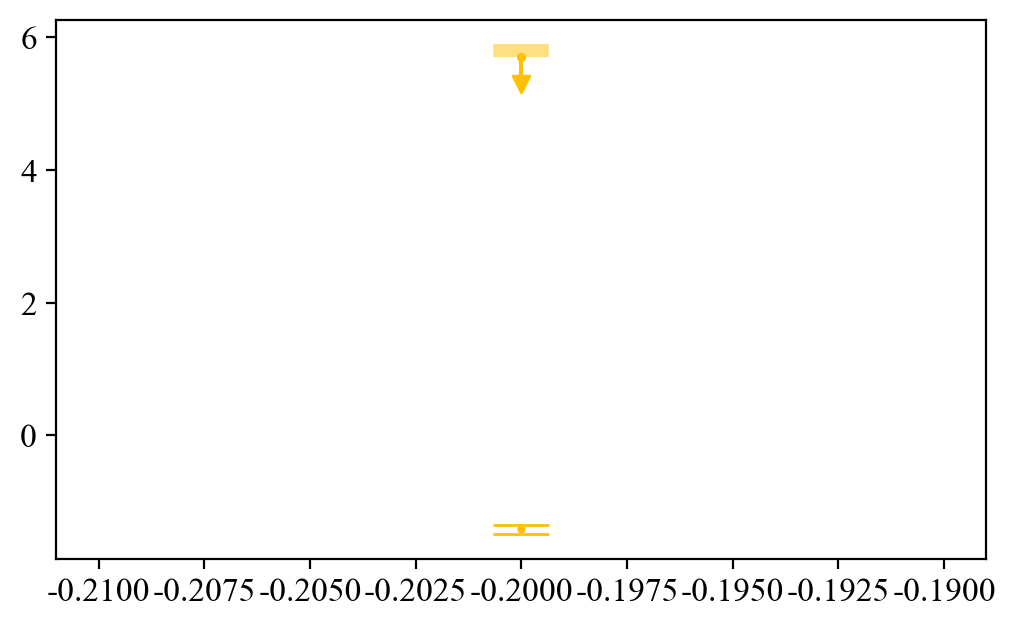

In [23]:
font = {'family' : 'times new roman',
         'size'   : 12,
         'serif':  'cmr10'
         }

plt.rc('font', **font)
plt.rc('axes', unicode_minus = False)

fig, ax = plt.subplots(figsize = (len(records_Fe), 3.5), dpi = 200)
x = np.arange(len(records_Fe))
x_left_offset = x - 0.2
x_right_offset = x + 0.2

nonzero_tau_mask = df_Fe["tau_Fe_sight_lines"] != 0
x_right_offset_nonzero = x_right_offset[nonzero_tau_mask.to_numpy()]
Fe_sight_lines_nonzero = df_Fe["Fe_sight_lines"][nonzero_tau_mask]
tau_Fe_sight_lines_nonzero = df_Fe["tau_Fe_sight_lines"][nonzero_tau_mask]

for i, row in df_Fe.iterrows():
    if i == 0:
        # ax.bar(x_left_offset[i], row["Fe_c"] - 7.32 + height, yerr = row["sigma_Fe_c"], width = 0.3, color = "#FFC000", edgecolor = "0", capsize = 5, bottom = -height, label = r"H II abundance")

        ax.errorbar(x_left_offset[i], row["Fe_c"] - 7.32, yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "#FFC000", label = r"HII abundance measurement or U/L limits from collisionally excited lines (CELs)")
        ax.scatter(x_left_offset[i], row["Fe_b"], marker = ".", s = 20, color = "#FFC000")
        ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_b"] - 0.45, color = "#FFC000")
        ax.scatter(x_left_offset[i], row["Fe_b"] - 0.4, marker = "v", color = "#FFC000")
        ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "#FFC000", alpha = 0.5)
        # "#ff00ff", edgecolor = "0", label = r"Mean co-spatial H I abundance")
    
        # ax.bar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 7.32 + height, yerr = df_Fe["se_Fe_sight_lines"][i], width = 0.3, capsize = 5, bottom = -height, color = elif i == 4:
        ax.bar(x_left_offset[i], row["Fe"] - 6.89 + height, yerr = row["sigma_Fe"], width = 0.3, color = "#FFC000", edgecolor = "0", capsize = 5, bottom = -height)
        ax.bar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 6.89 + height, yerr = df_Fe["se_Fe_sight_lines"][i], width = 0.3, capsize = 5, bottom = -height, color = "#a6ccd1", edgecolor = "0")
    elif i == 5:
        ax.scatter(x_left_offset[i], row["Fe_c"] - 6.89, marker = ".", s = 20, color = "0")
        ax.vlines(x_left_offset[i], row["Fe_c"] - 6.89, row["Fe_c"] - 6.89 - 0.45, color = "0")
        ax.scatter(x_left_offset[i], row["Fe_c"] - 6.89 - 0.45, marker = "v", color = "0", zorder = 100)
        ax.bar(x_left_offset[i], row["Fe_c"] - 6.89 + height, width = 0.3, color = "#FFC000", edgecolor = "0", capsize = 5, bottom = -height)
        ax.bar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 6.89 + height, yerr = df_Fe["se_Fe_sight_lines"][i], width = 0.3, capsize = 5, bottom = -height, color = "#a6ccd1", edgecolor = "0")
    elif i == 1:
        ax.bar(x_left_offset[i], row["Fe_c"] - 7.32 + height, yerr = row["sigma_Fe_c"], width = 0.3, color = "#FFC000", edgecolor = "0", capsize = 5, bottom = -height)
        ax.bar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 7.32 + height, yerr = df_Fe["se_Fe_sight_lines"][i], width = 0.3, capsize = 5, bottom = -height, color = "#a6ccd1", edgecolor = "0")
    else:
        ax.bar(x_left_offset[i], row["Fe_c"] - 6.89 + height, yerr = row["sigma_Fe_c"], width = 0.3, color = "#FFC000", edgecolor = "0", capsize = 5, bottom = -height)
        ax.bar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 6.89 + height, yerr = df_Fe["se_Fe_sight_lines"][i], width = 0.3, capsize = 5, bottom = -height, color = "#a6ccd1", edgecolor = "0")

for i in range(len(records_Fe)):
    ax.axvline(i + 0.5, linestyle = "-", linewidth = 1, color = "black")

ax.set_xticks(x)
ax.set_xticklabels(["30 Doradus", "N11B", "N66A", "N81", "N88A", "N90"])
# ax.set_ylabel(r"log$_{10}\frac{\text{gas phase}}{\text{stellar}}$")
ax.set_xlim(-0.5, len(records_Fe) - 0.5)
ax.set_ylim(-3, 0)
ax.set_title("Gas Phase Iron (Fe) Abundances in the Magellanic Clouds")
ax.minorticks_on()
ax.xaxis.set_tick_params(which = "minor", bottom = False)
ax.legend(fontsize = 12)

fig.tight_layout()
plt.savefig('Figure 1.1.png', dpi = 300)
plt.show()

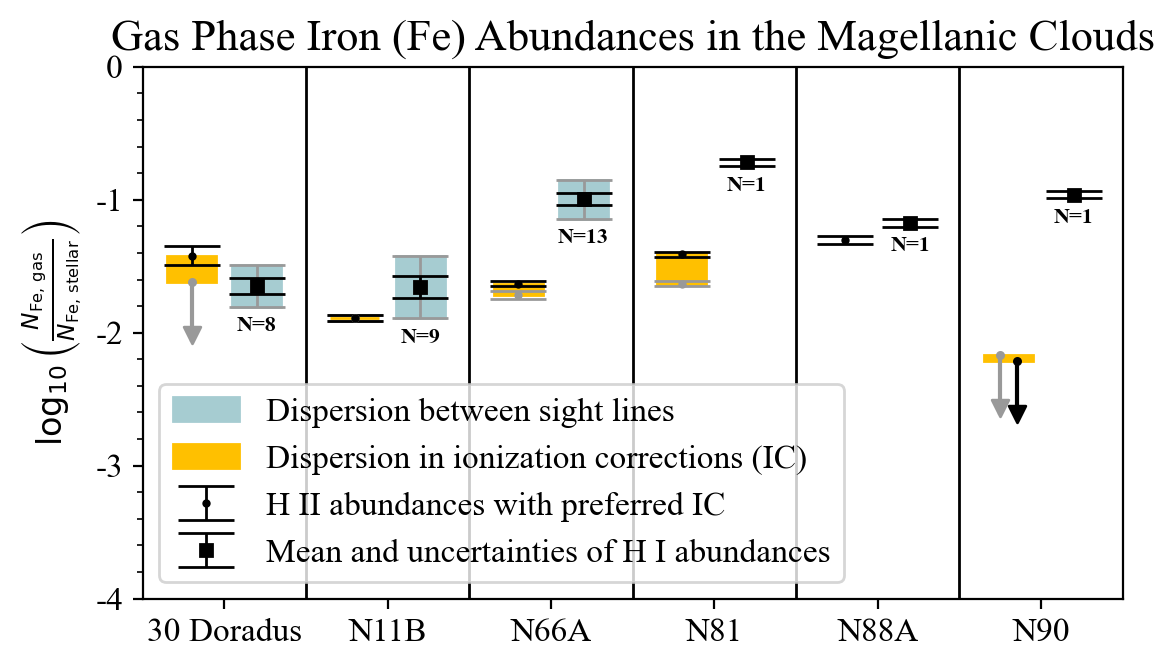

In [24]:
fig, ax = plt.subplots(figsize = (len(records_Fe), 3.5), dpi = 200)
x = np.arange(len(records_Fe))
x_left_offset = x - 0.2
x_right_offset = x + 0.2

shade_width = 0.3

for i, (xi, y, tau) in enumerate(zip(x_right_offset, df_Fe["Fe_sight_lines"], df_Fe["tau_Fe_sight_lines"])):
    if i == 0:
        if tau != 0: 
            rect = Rectangle((xi - shade_width / 2, y - tau - 7.32), shade_width, 2 * tau, facecolor = "#A6CCD1", edgecolor = "#A6CCD1", label = r"Dispersion between sight lines")
            ax.add_patch(rect)
    elif i == 1:
        if tau != 0: 
            rect = Rectangle((xi - shade_width / 2, y - tau - 7.32), shade_width, 2 * tau, facecolor = "#A6CCD1", edgecolor = "#A6CCD1")
            ax.add_patch(rect)
    else:
        if tau != 0: 
            rect = Rectangle((xi - shade_width / 2, y - tau - 6.89), shade_width, 2 * tau, facecolor = "#A6CCD1", edgecolor = "#A6CCD1")
            ax.add_patch(rect)

for i, (xi, y, count, se, tau) in enumerate(zip(x_right_offset, df_Fe["Fe_sight_lines"], df_Fe["sight_lines_count"], df_Fe["se_Fe_sight_lines"], df_Fe["tau_Fe_sight_lines"])):
    if i == 0 or i == 1:
        bottom = np.maximum(se, tau)
        ax.text(xi, y - bottom - 0.15 - 7.32, f"N={count}", color = "black", fontsize = 8, ha = "center", va = "center", weight = "bold")
    else:
        bottom = np.maximum(se, tau)
        ax.text(xi, y - bottom - 0.15 - 6.89, f"N={count}", color = "black", fontsize = 8, ha = "center", va = "center", weight = "bold")

for i, row in df_Fe.iterrows():
    if i == 0:
        ax.errorbar(x_left_offset[i], row["Fe_c"] - 7.32, yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0", label = r"H II abundances with preferred IC")
        ax.scatter(x_left_offset[i], row["Fe_b"] - 7.32, marker = ".", s = 20, color = "0.6")
        ax.vlines(x_left_offset[i], row["Fe_b"] - 7.32, row["Fe_b"] - 7.32 - 0.45, color = "0.6")
        ax.scatter(x_left_offset[i], row["Fe_b"] - 7.32 - 0.4, marker = "v", color = "0.6")
        # ax.vlines(x_left_offset[i], row["Fe_b"] - 7.32, row["Fe_c"] - 7.32, linewidth = 20, color = "#FFC000", zorder = 0)

        rect = Rectangle((x_left_offset[i] - shade_width / 2, (row["Fe_b"] + row["Fe_c"]) / 2 - 7.32 - (row["Fe_b"] - row["Fe_c"]) / 2), shade_width, (row["Fe_b"] - row["Fe_c"]), facecolor = "#FFC000", edgecolor = "#FFC000", zorder = 0, label = "Dispersion in ionization corrections (IC)")
        ax.add_patch(rect)
        ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 7.32, yerr = df_Fe["se_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0", ecolor = "0", label = r"Mean and uncertainties of H I abundances", zorder = 100)
        ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 7.32, yerr = df_Fe["tau_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0.6", ecolor = "0.6")
    elif i == 4:
        # ax.errorbar(x_left_offset[i], row["Fe_b"], yerr = row["sigma_Fe_b"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        # ax.errorbar(x_left_offset[i], row["Fe_c"], yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        # ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "0", alpha = 0.5)
        ax.errorbar(x_left_offset[i], row["Fe"] - 6.89, yerr = row["sigma_Fe"], fmt = ".", markersize = 4, capsize = 10, color = "0") # , label = r"HII abundance measurement from collisionally excited lines (CELs)")
        ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 6.89, yerr = df_Fe["se_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0", ecolor = "0", zorder = 100)
    elif i == 5:
        ax.scatter(x_left_offset[i] - 0.05, row["Fe_b"] - 6.89, marker = ".", s = 20, color = "0.6")
        ax.vlines(x_left_offset[i] - 0.05, row["Fe_b"] - 6.89, row["Fe_b"] - 6.89 - 0.45, color = "0.6")
        ax.scatter(x_left_offset[i] - 0.05, row["Fe_b"] - 6.89 - 0.4, marker = "v", color = "0.6")

        ax.scatter(x_left_offset[i] + 0.05, row["Fe_c"] - 6.89, marker = ".", s = 20, color = "0")
        ax.vlines(x_left_offset[i] + 0.05, row["Fe_c"] - 6.89, row["Fe_b"] - 6.89 - 0.45, color = "0")
        ax.scatter(x_left_offset[i] + 0.05, row["Fe_c"] - 6.89 - 0.4, marker = "v", color = "0")

        rect = Rectangle((x_left_offset[i] - shade_width / 2, (row["Fe_b"] + row["Fe_c"]) / 2 - 6.89 - (row["Fe_b"] - row["Fe_c"]) / 2), shade_width, (row["Fe_b"] - row["Fe_c"]), facecolor = "#FFC000", edgecolor = "#FFC000", zorder = 0)
        ax.add_patch(rect)
        ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 6.89, yerr = df_Fe["se_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0", ecolor = "0", zorder = 100)
    elif i == 1:
        ax.errorbar(x_left_offset[i], row["Fe_b"] - 7.32, yerr = row["sigma_Fe_b"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0.6")
        ax.errorbar(x_left_offset[i], row["Fe_c"] - 7.32, yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        rect = Rectangle((x_left_offset[i] - shade_width / 2, (row["Fe_b"] + row["Fe_c"]) / 2 - 7.32 - (row["Fe_b"] - row["Fe_c"]) / 2), shade_width, (row["Fe_b"] - row["Fe_c"]), facecolor = "#FFC000", edgecolor = "#FFC000", zorder = 0)
        ax.add_patch(rect)
        ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 7.32, yerr = df_Fe["se_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0", ecolor = "0", zorder = 100)
        ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 7.32, yerr = df_Fe["tau_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0.6", ecolor = "0.6")
    else:
        ax.errorbar(x_left_offset[i], row["Fe_b"] - 6.89, yerr = row["sigma_Fe_b"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0.6")
        ax.errorbar(x_left_offset[i], row["Fe_c"] - 6.89, yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        rect = Rectangle((x_left_offset[i] - shade_width / 2, (row["Fe_b"] + row["Fe_c"]) / 2 - 6.89 - (row["Fe_b"] - row["Fe_c"]) / 2), shade_width, (row["Fe_b"] - row["Fe_c"]), facecolor = "#FFC000", edgecolor = "#FFC000", zorder = 0)
        ax.add_patch(rect)
        ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 6.89, yerr = df_Fe["se_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0", ecolor = "0", zorder = 100)
        if i == 2:
            ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 6.89, yerr = df_Fe["tau_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0.6", ecolor = "0.6")

for i in range(len(records_Fe)):
    ax.axvline(i + 0.5, linestyle = "-", linewidth = 1, color = "black")

ax.set_xticks(x)
ax.set_xticklabels(["30 Doradus", "N11B", "N66A", "N81", "N88A", "N90"])
ax.set_xlim(-0.5, len(records_Fe) - 0.5)
ax.set_ylim(-4, 0)
ax.set_ylabel(r"$\log_{10}\left(\frac{N_\mathrm{Fe,\,gas}}{N_\mathrm{Fe,\,stellar}}\right)$")
ax.set_title("Gas Phase Iron (Fe) Abundances in the Magellanic Clouds", fontsize = 16)
ax.minorticks_on()
ax.xaxis.set_tick_params(which = "minor", bottom = False)
ax.legend(fontsize = 12)

fig.tight_layout()

plt.savefig('Figure 1.1.png', dpi = 300)
plt.show()

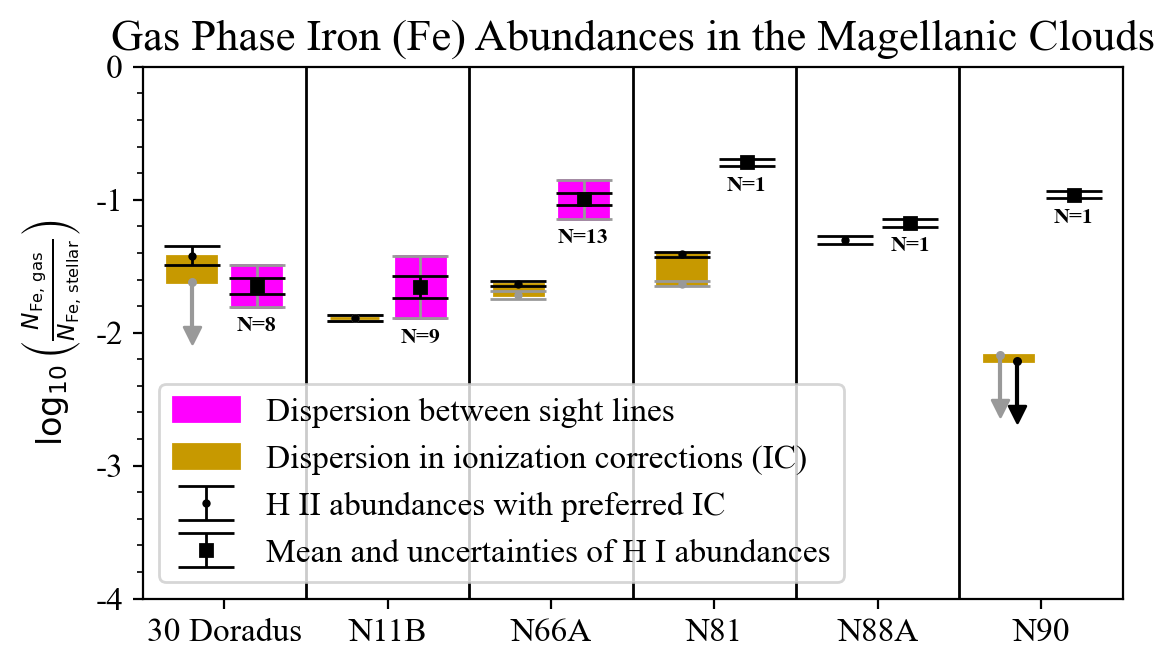

In [25]:
fig, ax = plt.subplots(figsize = (len(records_Fe), 3.5), dpi = 200)
x = np.arange(len(records_Fe))
x_left_offset = x - 0.2
x_right_offset = x + 0.2

shade_width = 0.3

for i, (xi, y, tau) in enumerate(zip(x_right_offset, df_Fe["Fe_sight_lines"], df_Fe["tau_Fe_sight_lines"])):
    if i == 0:
        if tau != 0: 
            rect = Rectangle((xi - shade_width / 2, y - tau - 7.32), shade_width, 2 * tau, facecolor = "#ff00ff", edgecolor = "#ff00ff", label = r"Dispersion between sight lines")
            ax.add_patch(rect)
    elif i == 1:
        if tau != 0: 
            rect = Rectangle((xi - shade_width / 2, y - tau - 7.32), shade_width, 2 * tau, facecolor = "#ff00ff", edgecolor = "#ff00ff")
            ax.add_patch(rect)
    else:
        if tau != 0: 
            rect = Rectangle((xi - shade_width / 2, y - tau - 6.89), shade_width, 2 * tau, facecolor = "#ff00ff", edgecolor = "#ff00ff")
            ax.add_patch(rect)

for i, (xi, y, count, se, tau) in enumerate(zip(x_right_offset, df_Fe["Fe_sight_lines"], df_Fe["sight_lines_count"], df_Fe["se_Fe_sight_lines"], df_Fe["tau_Fe_sight_lines"])):
    if i == 0 or i == 1:
        bottom = np.maximum(se, tau)
        ax.text(xi, y - bottom - 0.15 - 7.32, f"N={count}", color = "black", fontsize = 8, ha = "center", va = "center", weight = "bold")
    else:
        bottom = np.maximum(se, tau)
        ax.text(xi, y - bottom - 0.15 - 6.89, f"N={count}", color = "black", fontsize = 8, ha = "center", va = "center", weight = "bold")

for i, row in df_Fe.iterrows():
    if i == 0:
        ax.errorbar(x_left_offset[i], row["Fe_c"] - 7.32, yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0", label = r"H II abundances with preferred IC")
        ax.scatter(x_left_offset[i], row["Fe_b"] - 7.32, marker = ".", s = 20, color = "0.6")
        ax.vlines(x_left_offset[i], row["Fe_b"] - 7.32, row["Fe_b"] - 7.32 - 0.45, color = "0.6")
        ax.scatter(x_left_offset[i], row["Fe_b"] - 7.32 - 0.4, marker = "v", color = "0.6")
        # ax.vlines(x_left_offset[i], row["Fe_b"] - 7.32, row["Fe_c"] - 7.32, linewidth = 20, color = "#FFC000", zorder = 0)

        rect = Rectangle((x_left_offset[i] - shade_width / 2, (row["Fe_b"] + row["Fe_c"]) / 2 - 7.32 - (row["Fe_b"] - row["Fe_c"]) / 2), shade_width, (row["Fe_b"] - row["Fe_c"]), facecolor = "#C79900", edgecolor = "#C79900", zorder = 0, label = "Dispersion in ionization corrections (IC)")
        ax.add_patch(rect)
        ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 7.32, yerr = df_Fe["se_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0", ecolor = "0", label = r"Mean and uncertainties of H I abundances", zorder = 100)
        ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 7.32, yerr = df_Fe["tau_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0.6", ecolor = "0.6")
    elif i == 4:
        # ax.errorbar(x_left_offset[i], row["Fe_b"], yerr = row["sigma_Fe_b"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        # ax.errorbar(x_left_offset[i], row["Fe_c"], yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        # ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "0", alpha = 0.5)
        ax.errorbar(x_left_offset[i], row["Fe"] - 6.89, yerr = row["sigma_Fe"], fmt = ".", markersize = 4, capsize = 10, color = "0") # , label = r"HII abundance measurement from collisionally excited lines (CELs)")
        ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 6.89, yerr = df_Fe["se_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0", ecolor = "0", zorder = 100)
    elif i == 5:
        ax.scatter(x_left_offset[i] - 0.05, row["Fe_b"] - 6.89, marker = ".", s = 20, color = "0.6")
        ax.vlines(x_left_offset[i] - 0.05, row["Fe_b"] - 6.89, row["Fe_b"] - 6.89 - 0.45, color = "0.6")
        ax.scatter(x_left_offset[i] - 0.05, row["Fe_b"] - 6.89 - 0.4, marker = "v", color = "0.6")

        ax.scatter(x_left_offset[i] + 0.05, row["Fe_c"] - 6.89, marker = ".", s = 20, color = "0")
        ax.vlines(x_left_offset[i] + 0.05, row["Fe_c"] - 6.89, row["Fe_b"] - 6.89 - 0.45, color = "0")
        ax.scatter(x_left_offset[i] + 0.05, row["Fe_c"] - 6.89 - 0.4, marker = "v", color = "0")

        rect = Rectangle((x_left_offset[i] - shade_width / 2, (row["Fe_b"] + row["Fe_c"]) / 2 - 6.89 - (row["Fe_b"] - row["Fe_c"]) / 2), shade_width, (row["Fe_b"] - row["Fe_c"]), facecolor = "#C79900", edgecolor = "#C79900", zorder = 0)
        ax.add_patch(rect)
        ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 6.89, yerr = df_Fe["se_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0", ecolor = "0", zorder = 100)
    elif i == 1:
        ax.errorbar(x_left_offset[i], row["Fe_b"] - 7.32, yerr = row["sigma_Fe_b"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0.6")
        ax.errorbar(x_left_offset[i], row["Fe_c"] - 7.32, yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        rect = Rectangle((x_left_offset[i] - shade_width / 2, (row["Fe_b"] + row["Fe_c"]) / 2 - 7.32 - (row["Fe_b"] - row["Fe_c"]) / 2), shade_width, (row["Fe_b"] - row["Fe_c"]), facecolor = "#C79900", edgecolor = "#C79900", zorder = 0)
        ax.add_patch(rect)
        ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 7.32, yerr = df_Fe["se_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0", ecolor = "0", zorder = 100)
        ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 7.32, yerr = df_Fe["tau_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0.6", ecolor = "0.6")
    else:
        ax.errorbar(x_left_offset[i], row["Fe_b"] - 6.89, yerr = row["sigma_Fe_b"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0.6")
        ax.errorbar(x_left_offset[i], row["Fe_c"] - 6.89, yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "0")
        rect = Rectangle((x_left_offset[i] - shade_width / 2, (row["Fe_b"] + row["Fe_c"]) / 2 - 6.89 - (row["Fe_b"] - row["Fe_c"]) / 2), shade_width, (row["Fe_b"] - row["Fe_c"]), facecolor = "#C79900", edgecolor = "#C79900", zorder = 0)
        ax.add_patch(rect)
        ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 6.89, yerr = df_Fe["se_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0", ecolor = "0", zorder = 100)
        if i == 2:
            ax.errorbar(x_right_offset[i], df_Fe["Fe_sight_lines"][i] - 6.89, yerr = df_Fe["tau_Fe_sight_lines"][i], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0.6", ecolor = "0.6")

for i in range(len(records_Fe)):
    ax.axvline(i + 0.5, linestyle = "-", linewidth = 1, color = "black")

ax.set_xticks(x)
ax.set_xticklabels(["30 Doradus", "N11B", "N66A", "N81", "N88A", "N90"])
ax.set_xlim(-0.5, len(records_Fe) - 0.5)
ax.set_ylim(-4, 0)
ax.set_ylabel(r"$\log_{10}\left(\frac{N_\mathrm{Fe,\,gas}}{N_\mathrm{Fe,\,stellar}}\right)$")
ax.set_title("Gas Phase Iron (Fe) Abundances in the Magellanic Clouds", fontsize = 16)
ax.minorticks_on()
ax.xaxis.set_tick_params(which = "minor", bottom = False)
ax.legend(fontsize = 12)

fig.tight_layout()

plt.savefig('Poster figure 2.png', dpi = 300)
plt.show()

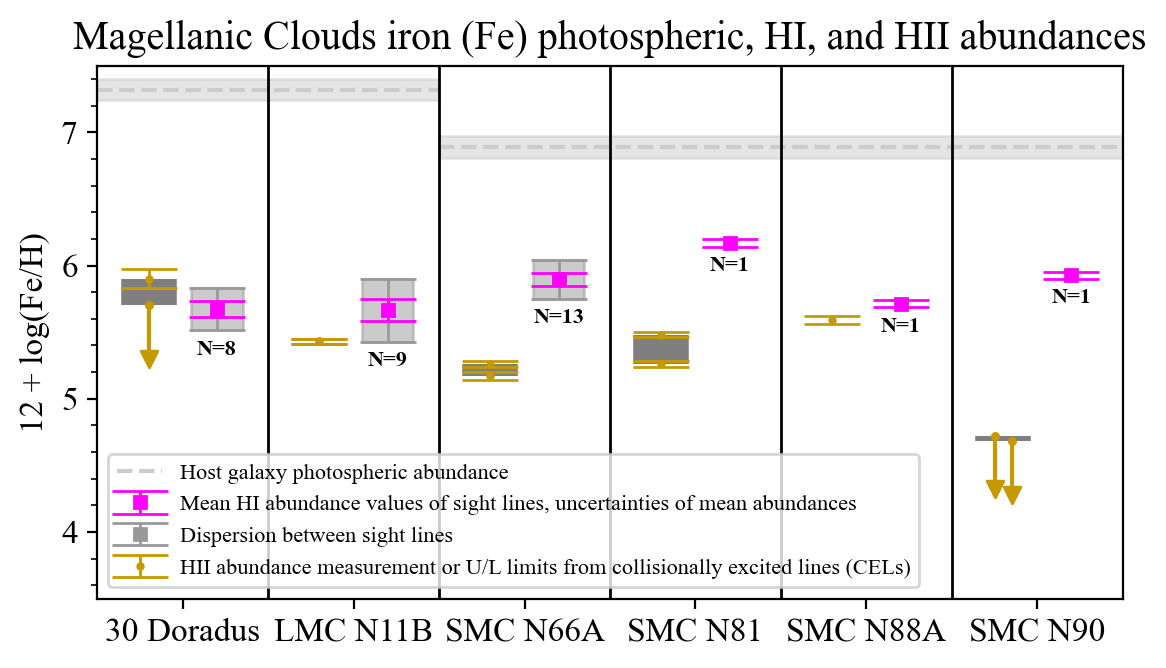

In [26]:
fig, ax = plt.subplots(figsize = (len(records_Fe), 3.5), dpi = 200)
x = np.arange(len(records_Fe))
x_left_offset = x - 0.2
x_right_offset = x + 0.2

ax.fill_between([-0.5, 1.5], 7.32 - 0.08, 7.32 + 0.08, alpha = 0.5, color = "0.8")
ax.hlines(7.32, xmin = -0.5, xmax = 1.5, color = "0.8", linestyle = "--", label = "Host galaxy photospheric abundance")
ax.fill_between([1.5, 5.5], 6.89 - 0.08, 6.89 + 0.08, alpha = 0.5, color = "0.8")
ax.hlines(6.89, xmin = 1.5, xmax = 5.5, color = "0.8", linestyle = "--")
ax.fill_between([5.5, 6.5], 6.04 - 0.2, 6.04 + 0.2, alpha = 0.2, color = "0.8")
ax.hlines(6.04, xmin = 5.5, xmax = 6.5, color = "0.8", linestyle = "--")

ax.errorbar(x_right_offset, df_Fe["Fe_sight_lines"], yerr = df_Fe["se_Fe_sight_lines"], fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "#ff00ff", ecolor = "#ff00ff", label = r"Mean HI abundance values of sight lines, uncertainties of mean abundances", zorder = 100)

nonzero_tau_mask = df_Fe["tau_Fe_sight_lines"] != 0
x_right_offset_nonzero = x_right_offset[nonzero_tau_mask.to_numpy()]
Fe_sight_lines_nonzero = df_Fe["Fe_sight_lines"][nonzero_tau_mask]
tau_Fe_sight_lines_nonzero = df_Fe["tau_Fe_sight_lines"][nonzero_tau_mask]
ax.errorbar(x_right_offset_nonzero, Fe_sight_lines_nonzero, yerr = tau_Fe_sight_lines_nonzero, fmt = "s", markersize = 4, capsize = 10, lw = 1, color = "0.6", ecolor = "0.6", label = r"Dispersion between sight lines")

shade_width = 0.3

for xi, y, tau in zip(x_right_offset, df_Fe["Fe_sight_lines"], df_Fe["tau_Fe_sight_lines"]):
    if tau != 0: 
        rect = Rectangle((xi - shade_width / 2, y - tau), shade_width, 2 * tau, facecolor = "0.6", edgecolor = "0.6", alpha = 0.5)
        ax.add_patch(rect)

for xi, y, count, se, tau in zip(x_right_offset, df_Fe["Fe_sight_lines"], df_Fe["sight_lines_count"], df_Fe["se_Fe_sight_lines"], df_Fe["tau_Fe_sight_lines"]):
    bottom = np.maximum(se, tau)
    ax.text(xi, y - bottom - 0.15, f"N={count}", color = "black", fontsize = 8, ha = "center", va = "center", weight = "bold")

for i, row in df_Fe.iterrows():
    if i == 0:
        ax.errorbar(x_left_offset[i], row["Fe_c"], yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "#C79900", label = r"HII abundance measurement or U/L limits from collisionally excited lines (CELs)")
        ax.scatter(x_left_offset[i], row["Fe_b"], marker = ".", s = 20, color = "#C79900")
        ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_b"] - 0.45, color = "#C79900")
        ax.scatter(x_left_offset[i], row["Fe_b"] - 0.4, marker = "v", color = "#C79900")
        ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "0", alpha = 0.5, zorder = 0)
    elif i == 4:
        # ax.errorbar(x_left_offset[i], row["Fe_b"], yerr = row["sigma_Fe_b"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "#C79900")
        # ax.errorbar(x_left_offset[i], row["Fe_c"], yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "#C79900")
        # ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "#C79900", alpha = 0.5)
        ax.errorbar(x_left_offset[i], row["Fe"], yerr = row["sigma_Fe"], fmt = ".", markersize = 4, capsize = 10, color = "#C79900") # , label = r"HII abundance measurement from collisionally excited lines (CELs)")
    elif i == 5:
        ax.scatter(x_left_offset[i] - 0.05, row["Fe_b"], marker = ".", s = 20, color = "#C79900")
        ax.vlines(x_left_offset[i] - 0.05, row["Fe_b"], row["Fe_b"] - 0.45, color = "#C79900")
        ax.scatter(x_left_offset[i] - 0.05, row["Fe_b"] - 0.4, marker = "v", color = "#C79900")

        ax.scatter(x_left_offset[i] + 0.05, row["Fe_c"], marker = ".", s = 20, color = "#C79900")
        ax.vlines(x_left_offset[i] + 0.05, row["Fe_c"], row["Fe_b"] - 0.45, color = "#C79900")
        ax.scatter(x_left_offset[i] + 0.05, row["Fe_c"] - 0.4, marker = "v", color = "#C79900")

        ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "0", alpha = 0.5, zorder = 0)
    else:
        ax.errorbar(x_left_offset[i], row["Fe_b"], yerr = row["sigma_Fe_b"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "#C79900")
        ax.errorbar(x_left_offset[i], row["Fe_c"], yerr = row["sigma_Fe_c"], fmt = ".", markersize = 4, capsize = 10, lw = 1, color = "#C79900")
        ax.vlines(x_left_offset[i], row["Fe_b"], row["Fe_c"], linewidth = 20, color = "0", alpha = 0.5, zorder = 0)

for i in range(len(records_Fe)):
    ax.axvline(i + 0.5, linestyle = "-", linewidth = 1, color = "black")

ax.set_xticks(x)
ax.set_xticklabels(df_Fe["region"])
ax.set_ylabel(r"12 + log(Fe/H)")
ax.set_xlim(-0.5, len(records_Fe) - 0.5)
ax.set_ylim(3.5, 7.5)
ax.set_title("Magellanic Clouds iron (Fe) photospheric, HI, and HII abundances")
ax.minorticks_on()
ax.xaxis.set_tick_params(which = "minor", bottom = False)
ax.legend(fontsize = 8)

fig.tight_layout()

plt.savefig('Poster figure 2.png', dpi = 300)
plt.show()

In [ ]:
# END